# Puzzle

### This Week’s Fiddler
The Fiddler Baseball League consists of exactly two teams of equal skill: the Algebraists and the Geometers. Over the course of a season, these two teams play each other 162 times. Each team has an equal chance of winning each game, and the results of games are independent of one another.

At the end of the season, on average, how many games would you expect the team with the better record to have won? (If the teams have the same record, then you should include one of them in your calculation.)

### This Week’s Extra Credit
After some expansion, the Fiddler Baseball League now boasts 30 teams. Over the course of a season, each team plays each other team five times. (Thus, each team plays a total of 145 games.) As before, each team has an equal chance of winning each game, and the results of games are independent of one another.

At the end of the season, on average, how many games would you expect the team with the best record to have won? (If more than one team has the same best record, then you should include one of them in your calculation.)

# Fiddler Solution.

This is a straightforward expression

$ \sum_{k=0}^{n} max(k,(n-k)) \times {n \choose k} \times 2^{-n} $

Even though this is close to some standard expressions ( e.g. (6) in https://en.wikipedia.org/wiki/Binomial_coefficient#Sums_of_the_binomial_coefficients ), I am not sure how to calculate this exactly, so I'll do it numerically.

In [46]:
import numpy as np
from scipy.stats import binom

def calculate_expected_max_wins(n, p=0.5):
    """
    Calculate the expected maximum number of wins in n games.

    Parameters:
    n (int): The number of games played.

    Returns:
    float: The expected maximum number of wins.
    """
    # Calculate the expected maximum number of wins
    expected_max_wins = 0
    for k in range(n + 1):
        prob_k_wins = binom.pmf(k, n, p)
        max_wins = max(k, n - k)
        expected_max_wins += max_wins * prob_k_wins

    return expected_max_wins

Fiddler_answer = calculate_expected_max_wins(162)

print(f"Expected maximum number of wins in 162 games: {Fiddler_answer:.6f}")

Expected maximum number of wins in 162 games: 86.069876


Okay, so the answer is 86.07, and it is not that far from the expected number of games won (81). That makes sense because n = 162 is so large that most of the distribution is in the center. So, even after scaling each term with the corresponding max wins the distribution is still very much in the center.

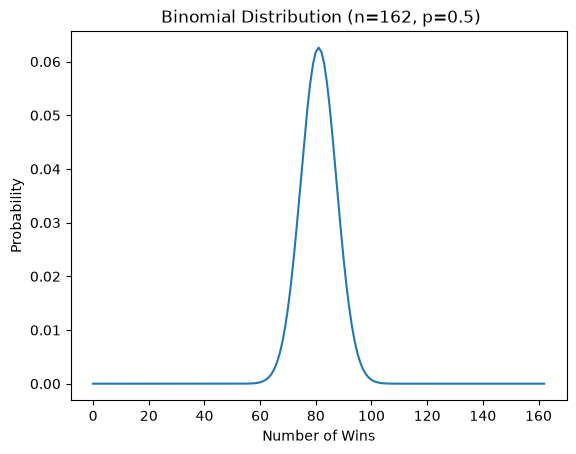

In [42]:
import matplotlib.pyplot as plt
n = 162
k = np.arange(0, n + 1)
probabilities = binom.pmf(k, n, 0.5)

plt.plot(k, probabilities, '-', label='PMF of Binomial Distribution')
plt.xlabel('Number of Wins')
plt.ylabel('Probability')
plt.title(' Binomial Distribution (n=162, p=0.5)')
#plt.grid()
#plt.legend()
plt.show()

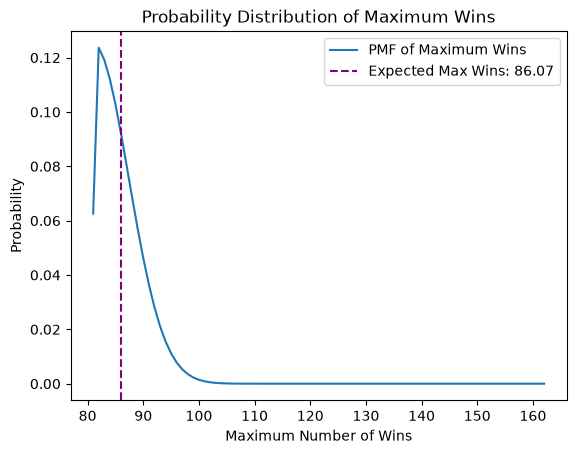

In [43]:
n = 162
maxs = range(n//2, n + 1)
probabilities_max = [binom.pmf(k, n, 0.5) + binom.pmf(n - k, n, 0.5) if (k > n//2) else binom.pmf(k, n, 0.5) for k in maxs]

plt.plot(maxs, probabilities_max, '-', label='PMF of Maximum Wins')
plt.xlabel('Maximum Number of Wins')
plt.ylabel('Probability')
plt.title('Probability Distribution of Maximum Wins')
#plt.grid()
plt.axvline(x=Fiddler_answer, color='purple', linestyle='--', label=f'Expected Max Wins: {Fiddler_answer:.2f}')
plt.legend()
plt.show()

# Extra Credit Solution

Here, an analytical solution seems even more out of reach, so I'm going to fall back to monte carlo. Trying to do it with numpy this time to be more efficient.

In [44]:
#r = binom.rvs(5, 0.5, size=100)
#print(f"Random samples from Binomial distribution (n=5, p=0.5): {np.sort(r)}")
# Looks good.

In [47]:
import numpy as np
from scipy.stats import binom

def mc_exp_max_wins(num_teams=30, games_per_opponent=5, num_seasons=10, p=0.5):
    # Each pair of teams is independent, so we organize the matrix by pairs of teams rather than individual matches.
    matrix = np.zeros((num_teams, num_teams, num_seasons), dtype=int)
    for team in range(num_teams):
        for opponent in range(team + 1, num_teams):
            team_wins = binom.rvs(games_per_opponent, p, size=num_seasons)
            opponent_wins = games_per_opponent - team_wins
            matrix[team, opponent] = team_wins
            matrix[opponent, team] = opponent_wins
    m_sum = np.sum(matrix, axis=1)  # Sum wins for each team across all opponents
    m_max = np.max(m_sum, axis=0)  # Max wins for each season
    m_avg = np.mean(m_max)  # Average max wins across seasons
    print(f"m_avg: {m_avg}")
    return m_avg

Fiddler_check = mc_exp_max_wins(num_teams=2, games_per_opponent=162, num_seasons=1000000)
print(f"Expected maximum number of wins in 162 games (2 teams): Fiddler Cross-check: {Fiddler_check:.4f}\n\n")

EC_reference = mc_exp_max_wins(num_teams=2, games_per_opponent=145, num_seasons=1000000)
print(f"Expected maximum number of wins in 145 games (2 teams): EC Reference: {EC_reference:.4f}\n\n")

from scipy.stats import describe
EC_run_results = []
for _ in range(10):
    EC_run_results.append(mc_exp_max_wins(num_seasons=1000000))
print(f"Descriptive statistics for EC_run_results:")
print(describe(EC_run_results))

m_avg: 86.077615
Expected maximum number of wins in 162 games (2 teams): Fiddler Cross-check: 86.0776


m_avg: 77.314718
Expected maximum number of wins in 145 games (2 teams): EC Reference: 77.3147


m_avg: 84.983586
m_avg: 84.979494
m_avg: 84.987147
m_avg: 84.983848
m_avg: 84.984246
m_avg: 84.983583
m_avg: 84.981987
m_avg: 84.980941
m_avg: 84.983327
m_avg: 84.979774
Descriptive statistics for EC_run_results:
DescribeResult(nobs=np.int64(10), minmax=(np.float64(84.979494), np.float64(84.987147)), mean=np.float64(84.9827933), variance=np.float64(5.3107728999845565e-06), skewness=np.float64(0.1682987057359219), kurtosis=np.float64(-0.46283729026660625))


# Extra Extra Credit, i.e. Extension

Looking at the [official baseball schedule](https://en.wikipedia.org/wiki/Major_League_Baseball_schedule), it seems not too hard to extend this to the actual 162 game schedule.

> Beginning with the 2025 season, teams play a balanced schedule as follows: thirteen games are played against each of the other four teams in their own division (52 games total), six or seven games against each of the other ten teams in their own league (62 games total), six games against one "geographic rival" from the other league, and three games against each of the other fourteen teams from the other league, for 48 total interleague games

In [49]:
def mlb_games_between(i, j, year=2025):
    """ Years other than 2025 are not supported. """
    if year != 2025:
        raise ValueError("Only the year 2025 is supported.")
    # 13 games × 4 opponents in-division (52 games),
    # 6 games × 8 opponents and 7 games × 2 opponents interdivision within same league (62 games),
    # 6 games × 1 interleague rival opponent and 3 games × 14 interleague opponents (48 games)
    i_league, i_mod15 = divmod(i, 15)
    j_league, j_mod15 = divmod(j, 15)
    i_division, i_mod5 = divmod(i_mod15, 5)
    j_division, j_mod5 = divmod(j_mod15, 5)
    if i == j:
        return 0
    elif i_league == j_league:
        if i_division == j_division:
            return 13
            # 13 games against each of the teams in the same division (4 opponents)
        else:
            return 7 if (i_mod5 == j_mod5) else 6
            # 7 games against matching interdivision opponents (2 opponents), 6 games against non-matching interdivision opponents (8 opponents)
    else:
        return 6 if (i_mod15 == j_mod15) else 3
        # 6 games against matching interleague opponents, 3 games against non-matching interleague opponents (14 opponents)

def mlb_mc_exp_max_wins(num_seasons=10, p=0.5):
    num_teams=30
    # Each pair of teams is independent, so we organize the matrix by pairs of teams rather than individual matches.
    matrix = np.zeros((num_teams, num_teams, num_seasons), dtype=int)
    for team in range(num_teams):
        for opponent in range(team + 1, num_teams):
            games_between = mlb_games_between(team, opponent)
            team_wins = binom.rvs(games_between, p, size=num_seasons)
            opponent_wins = games_between - team_wins
            matrix[team, opponent] = team_wins
            matrix[opponent, team] = opponent_wins
    m_sum = np.sum(matrix, axis=1)  # Sum wins for each team across all opponents
    m_max = np.max(m_sum, axis=0)  # Max wins for each season
    m_avg = np.mean(m_max)  # Average max wins across seasons
    print(f"m_avg: {m_avg}")
    return m_avg

EEC_run_results = []
for _ in range(10):
    EEC_run_results.append(mlb_mc_exp_max_wins(num_seasons=1000000))
print(f"Descriptive statistics for EEC_run_results:")
print(describe(EEC_run_results))

m_avg: 94.188811
m_avg: 94.195484
m_avg: 94.197235
m_avg: 94.186925
m_avg: 94.190843
m_avg: 94.192485
m_avg: 94.195648
m_avg: 94.192971
m_avg: 94.194214
m_avg: 94.191884
Descriptive statistics for EEC_run_results:
DescribeResult(nobs=np.int64(10), minmax=(np.float64(94.186925), np.float64(94.197235)), mean=np.float64(94.19265), variance=np.float64(1.0220410888890909e-05), skewness=np.float64(-0.3606782397653947), kurtosis=np.float64(-0.7595169805309756))


# Conclusion

Fiddler answer - expected max wins between 2 teams playing 162 games - is 86.069876, and that is supported by the simulation, but I am not sure of the confidence interval because of possible numerical effects. 86.07 (0.531 win pct) seems like a safe conclusion.

Extra Credit answer - expected max wins between 30 teams playing 145 games each - is 84.98 (0.586 win pct). I don't think we have enough precision to define any more digits. This is significantly more than the expected max wins between 2 games (77.3 (0.533 win pct)). That makes sense because 30 is a lot more than 2, so there are more chances that some team will rack up higher numbers of wins.

Extending this to the actual MLB schedule yields 94.19 (0.581 win pct). Pretty similar to the 0.586 win pct in the EC. But, that's a lot lower than the win pcts in 0.7 range seen in [this records page](https://en.wikipedia.org/wiki/List_of_best_Major_League_Baseball_season_win%E2%80%93loss_records). I guess teams differ in talent and baseball games are not just coin flips.

And finally, numpy is definitely a whole lot faster than my usual regular python code. I simulated 10 million seasons in 3 minutes of runtime.